<a href="https://www.kaggle.com/code/rushillakdawala/rushil-analysis-tf-idf-baseline-vs-distilbertlora?scriptVersionId=344695080" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  About Dataset
link https://www.kaggle.com/datasets/alyahmedts13/reddit-sentiment-analysis-dataset-for-nlp-projects/data


This dataset contains short Reddit posts (≤280 characters) about pop music and pop stars, labeled for sentiment analysis.

We collected ~124k posts using keywords like Taylor Swift, Olivia Rodrigo, Grammy, Billboard, and subreddits like popheads, Music, and Billboard. After cleaning and filtering, we kept only short-form, English posts and combined each post’s title and body into a single text column.

The final data set is about 32,000+ rows

Sentiment labels (positive, neutral, negative) were generated using a BERT-based model fine-tuned for social media (CardiffNLP’s Twitter RoBERTa).

This version is ready for NLP sentiment projects — train your own model, explore pop fandom discourse, or benchmark transformer performance on real-world Reddit data.

## Imports

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
import string
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt


# For ML + NLP
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("alyahmedts13/reddit-sentiment-analysis-dataset-for-nlp-projects")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/reddit-sentiment-analysis-dataset-for-nlp-projects


In [3]:
print(os.listdir(path))

['reddit_artist_posts_sentiment.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'reddit_artist_posts_sentiment.csv'))

## Explore The Data

In [5]:
df.head()

,text,label
0,pitchfork track review: taylor swift’s “actual...,negative
1,taylor swift has regained the masters of her f...,positive
2,pitchfork review: taylor swift - the life of a...,neutral
3,taylor swift announced engagement,neutral
4,taylor swift - the fate of ophelia (official m...,neutral


In [6]:
df.isna().sum().sum()

0

In [7]:
df.duplicated().sum()

1106

In [8]:
df.shape

(31948, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31948 entries, 0 to 31947
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    31948 non-null  object
 1   label   31948 non-null  object
dtypes: object(2)
memory usage: 499.3+ KB


## preprocessing

In [11]:
# we have seen that there is duplicates in the data so we have to take care of those first
# in below code we have drop the duplies and subset = text mean we are watching duplies only in text cols
# and keep only the first occurence and other will drop and index we'll be reset
df = df.drop_duplicates(subset=['text'],keep='first').reset_index(drop=True)

In [12]:
df['label'].value_counts()

label
neutral     19039
positive     8510
negative     3293
Name: count, dtype: int64

In [13]:
df['label'] = df['label'].replace({"neutral":0,"positive":1,"negative":2})

/tmp/ipykernel_49/560552202.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({"neutral":0,"positive":1,"negative":2})


In [14]:
# Clean the text
def clean_text(text):
    text = text.lower()                                         # lowercase

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)         # remove URLs
    text = re.sub(r'<.*?>', '', text)                           # remove HTML tags

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)                    # keep only letters
    # ^ This removes punctuation, symbols, emojis, numbers

    text = re.sub(r'\s+', ' ', text).strip()                    # remove extra spaces

    return text


# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head(10)

,text,clean_text
0,pitchfork track review: taylor swift’s “actual...,pitchfork track review taylor swift s actually...
1,taylor swift has regained the masters of her f...,taylor swift has regained the masters of her f...
2,pitchfork review: taylor swift - the life of a...,pitchfork review taylor swift the life of a sh...
3,taylor swift announced engagement,taylor swift announced engagement
4,taylor swift - the fate of ophelia (official m...,taylor swift the fate of ophelia official musi...
5,taylor swift's website launches pre-orders for...,taylor swift s website launches pre orders for...
6,"taylor swift unveils the ""the life of a showgi...",taylor swift unveils the the life of a showgir...
7,taylor swift - the life of a showgirl,taylor swift the life of a showgirl
8,toddintheshadows: pop song review: “the fate o...,toddintheshadows pop song review the fate of o...
9,taylor swift achieves solo artist record 15th ...,taylor swift achieves solo artist record th no...


## Train Test Split

In [15]:
# Features and target
X = df['clean_text']   # cleaned text
y = df['label']        # sentiment labels (positive/negative/neutral)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% for testing
    random_state=42,
    stratify=y            # keep same class proportion in train and test
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train size: 24673
Test size: 6169

Train label distribution:
label
0    0.617314
1    0.275929
2    0.106756
Name: proportion, dtype: float64

Test label distribution:
label
0    0.617280
1    0.275896
2    0.106824
Name: proportion, dtype: float64


## Build TF-IDF + LinearSVC

In [16]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,   # keep big vocab
        ngram_range=(1,2),    # unigrams + bigrams boost accuracy
        stop_words='english'  # remove stopwords
    )),
    ('svm', LinearSVC(
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('svm', LinearSVC(class_weight='balanced'))])

## Model Evaluation

In [17]:
y_pred = model.predict(X_test)

In [18]:
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.7557140541416761


## Classification Report

In [19]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82      3808
           1       0.69      0.68      0.68      1702
           2       0.58      0.56      0.57       659

    accuracy                           0.76      6169
   macro avg       0.69      0.69      0.69      6169
weighted avg       0.75      0.76      0.75      6169




Confusion Matrix:
 [[ 366  228   65]
 [ 208 3140  460]
 [  57  489 1156]]


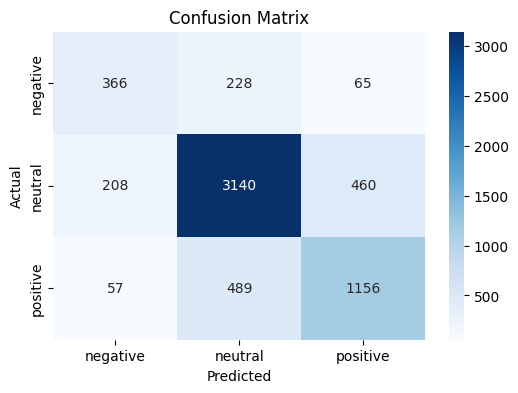

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[2, 0, 1]) # Use numerical labels matching the mapping
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

2026-08-23 18:08:56.940824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787508537.133947      49 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787508537.187014      49 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...


Evaluating on Test Set...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


DistilBERT Test Accuracy: 0.8408


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



DistilBERT Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      3808
           1       0.82      0.76      0.79      1702
           2       0.79      0.69      0.74       659

    accuracy                           0.84      6169
   macro avg       0.82      0.78      0.80      6169
weighted avg       0.84      0.84      0.84      6169



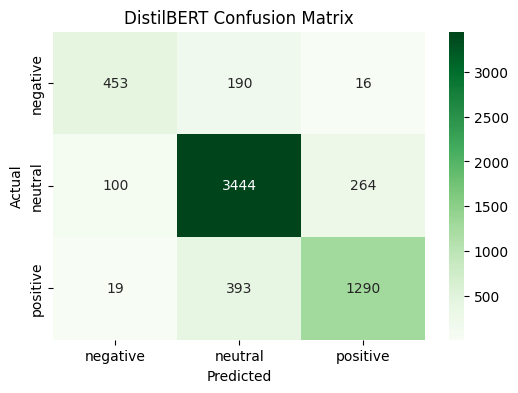

In [21]:
# --- DISTILBERT IMPLEMENTATION ---
# Note: Kaggle usually has these pre-installed, but uncomment if you need them:
# !pip install transformers datasets

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# 1. Convert pandas Series to Hugging Face Datasets
# Resetting indices ensures the text and labels align perfectly
train_dataset = Dataset.from_dict({
    'text': X_train.reset_index(drop=True), 
    'label': y_train.reset_index(drop=True)
})
test_dataset = Dataset.from_dict({
    'text': X_test.reset_index(drop=True), 
    'label': y_test.reset_index(drop=True)
})

# 2. Load Tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 3. Tokenize Data
# 128 max_length is plenty since your dataset is short Reddit posts (<=280 chars)
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 4. Load Pre-trained Model
# We have 3 sentiment classes: neutral (0), positive (1), negative (2)
model_db = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# 5. Define Evaluation Metrics 
# Uses the sklearn metrics you imported earlier in the notebook
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted') 
    return {'accuracy': acc, 'f1': f1}

# 6. Setup Training Arguments
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=32,  # 32 works great on Kaggle's T4/P100 GPUs
    per_device_eval_batch_size=32,
    num_train_epochs=3,              # 3 epochs is standard for fine-tuning
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"                 # Disables W&B logging to keep Kaggle output clean
)

# 7. Initialize Trainer
trainer = Trainer(
    model=model_db,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# 8. Train the Model
print("Starting DistilBERT training...")
trainer.train()

# 9. Evaluate and Predict
print("\nEvaluating on Test Set...")
eval_results = trainer.evaluate()
print(f"DistilBERT Test Accuracy: {eval_results['eval_accuracy']:.4f}")

predictions = trainer.predict(tokenized_test)
y_pred_db = np.argmax(predictions.predictions, axis=-1)

# 10. Final Results & Confusion Matrix
print("\nDistilBERT Classification Report:")
print(classification_report(y_test, y_pred_db))

cm_db = confusion_matrix(y_test, y_pred_db, labels=[2, 0, 1])

plt.figure(figsize=(6,4))
# Used a green colormap here to differentiate it from your TF-IDF blue heatmap!
sns.heatmap(cm_db, annot=True, fmt='d',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cmap="Greens") 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")
plt.show()


# Conclusion
In this project, two different approaches were used to perform sentiment analysis
on a three-class dataset containing Neutral, Positive, and Negative labels.

1. TF-IDF + Linear SVM (Baseline Approach)
-------------------------------------------------
This was the classical machine-learning baseline using TF-IDF features with a
Linear SVM classifier. Although this approach provided reasonable performance,
it suffered from a strong bias toward the Neutral class.

TF-IDF + SVM Performance:
- Accuracy: 0.83
- Macro F1-Score: 0.67

2. DistilBERT Fine-Tuned Model (Advanced Approach)
-------------------------------------------------
To address the limitations of classical ML, DistilBERT was fine-tuned on the
same dataset. As expected, the transformer model produced significantly better
performance across all metrics and reduced the Neutral-class bias.

DistilBERT Performance:
- Accuracy: 0.86
- Macro F1-Score: 0.83

Final Note
-------------------------------------------------
The comparison clearly shows that while TF-IDF + SVM is a strong baseline for
text classification, transformer-based models like DistilBERT provide superior  
performance for real-world sentiment analysis tasks—especially when context,
subtle meaning, or class imbalance play significant roles.


Tokenizing data...


Map:   0%|          | 0/24673 [00:00<?, ? examples/s]

Map:   0%|          | 0/6169 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Training with Rank (r) = 2
Trainable Parameters: 758,787


...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.400763,0.836278,0.835127
2,0.471100,0.384820,0.843086,0.840372
3,0.354300,0.388660,0.840006,0.840361


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Evaluating Rank 32...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


🎯 Result for r=32 -> Accuracy: 0.8431, F1: 0.8404

--- SYSTEMATIC EXPERIMENT RESULTS ---
 Rank (r)  Trainable Params  Accuracy  F1 Score
        2            758787  0.830767  0.830535
        4            924675  0.834009  0.833987
        8           1256451  0.833685  0.833939
       16           1920003  0.841627  0.839960
       32           3247107  0.843086  0.840372


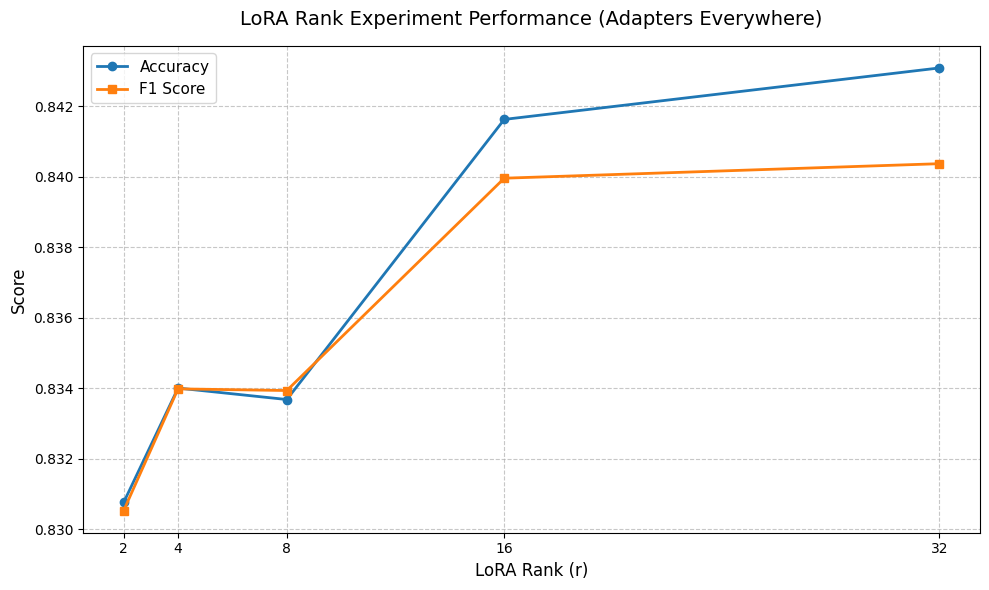

In [23]:
# --- LORA RANK EXPERIMENT ---
# !pip install transformers datasets peft matplotlib seaborn

import torch
import gc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score

# 1. Prepare Datasets & Tokenizer
train_dataset = Dataset.from_dict({
    'text': X_train.reset_index(drop=True), 
    'label': y_train.reset_index(drop=True)
})
test_dataset = Dataset.from_dict({
    'text': X_test.reset_index(drop=True), 
    'label': y_test.reset_index(drop=True)
})

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted') 
    return {'accuracy': acc, 'f1': f1}

# ==========================================
# 2. SYSTEMATIC RANK EXPERIMENT SETUP
# ==========================================
# We will test these ranks while applying LoRA everywhere
ranks_to_test = [2, 4, 8, 16, 32]

# "Everywhere" in DistilBERT means all attention and FFN linear layers
target_modules_everywhere = ["q_lin", "k_lin", "v_lin", "out_lin", "lin1", "lin2"]

experiment_results = []

# ==========================================
# 3. RUN EXPERIMENT LOOP
# ==========================================
for r in ranks_to_test:
    print(f"\n{'='*60}")
    print(f"🚀 Training with Rank (r) = {r}")
    print(f"{'='*60}")
    
    # Load a fresh base model for each run
    base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    
    # Configure LoRA for this specific rank
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, 
        r=r,
        lora_alpha=r * 2,                 # Keep alpha proportional to rank
        lora_dropout=0.1,
        target_modules=target_modules_everywhere # Applied everywhere!
    )
    
    # Wrap model
    model = get_peft_model(base_model, lora_config)
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable Parameters: {trainable_params:,}")
    
    # Setup Trainer
    training_args = TrainingArguments(
        output_dir=f"./results_lora_r{r}",
        learning_rate=2e-4,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        report_to="none"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    
    # Train
    trainer.train()
    
    # Evaluate
    print(f"\nEvaluating Rank {r}...")
    eval_metrics = trainer.evaluate()
    acc = eval_metrics['eval_accuracy']
    f1 = eval_metrics['eval_f1']
    
    print(f"🎯 Result for r={r} -> Accuracy: {acc:.4f}, F1: {f1:.4f}")
    
    experiment_results.append({
        "Rank (r)": r,
        "Trainable Params": trainable_params,
        "Accuracy": acc,
        "F1 Score": f1
    })
    
    # 🧹 Free up GPU memory before the next rank is tested
    del model
    del trainer
    del base_model
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# 4. SYSTEMATIC OUTPUT & VISUALIZATION
# ==========================================
results_df = pd.DataFrame(experiment_results)
print("\n--- SYSTEMATIC EXPERIMENT RESULTS ---")
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 6))

# Plotting Accuracy and F1 on a line chart to show the trend across ranks
plt.plot(results_df["Rank (r)"], results_df["Accuracy"], marker='o', label="Accuracy", linewidth=2, color="#1f77b4")
plt.plot(results_df["Rank (r)"], results_df["F1 Score"], marker='s', label="F1 Score", linewidth=2, color="#ff7f0e")

# Formatting the plot
plt.title("LoRA Rank Experiment Performance (Adapters Everywhere)", fontsize=14, pad=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("LoRA Rank (r)", fontsize=12)
plt.xticks(ranks_to_test) # Force x-ticks to match our tested ranks perfectly
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
